In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal

In [45]:
# --- PARÀMETRES ---
m = 0.02   # kg
c = 1.25   # Ns/m
k = 5500   # N/m

In [46]:
# --- SISTEMA LTI ---
sys = signal.lti([1], [m, c, k])

# --- POLES ---
p = sys.poles

In [49]:
omega_n = np.sqrt(k/m)
zeta = c / (2*np.sqrt(k*m))
omega_r = omega_n * np.sqrt(1 - zeta**2)

print('\n' + '-'*60)
print(f"{'Paràmetre':>12} | {'Valor':>20}")
print('-'*60)

print(f"{'omega_n':>12} | {omega_n:20.2f}  rad/s")
print(f"{'zeta':>12} | {zeta:20.4f}")
print(f"{'omega_r':>12} | {omega_r:20.2f}  rad/s")

print(f"{'pols':>12} |")
for pole in p:
    print(f"{'':>12} | {pole.real:8.2f} {pole.imag:+8.2f}j")

print('-'*60 + '\n')



------------------------------------------------------------
   Paràmetre |                Valor
------------------------------------------------------------
     omega_n |               524.40  rad/s
        zeta |               0.0596
     omega_r |               523.47  rad/s
        pols |
             |   -31.25  +523.47j
             |   -31.25  -523.47j
------------------------------------------------------------



A) RESPOSTA FREQÜENCIAL ANALÍTICA

In [ ]:
omg = np.arange(400, 800, 0.1)
Omega = omg / omega_n

H_omg = 1 / np.sqrt((1 - Omega**2)**2 + (2*zeta*Omega)**2)
Theta_omg = np.arctan2(2*zeta*Omega, (1 - Omega**2))

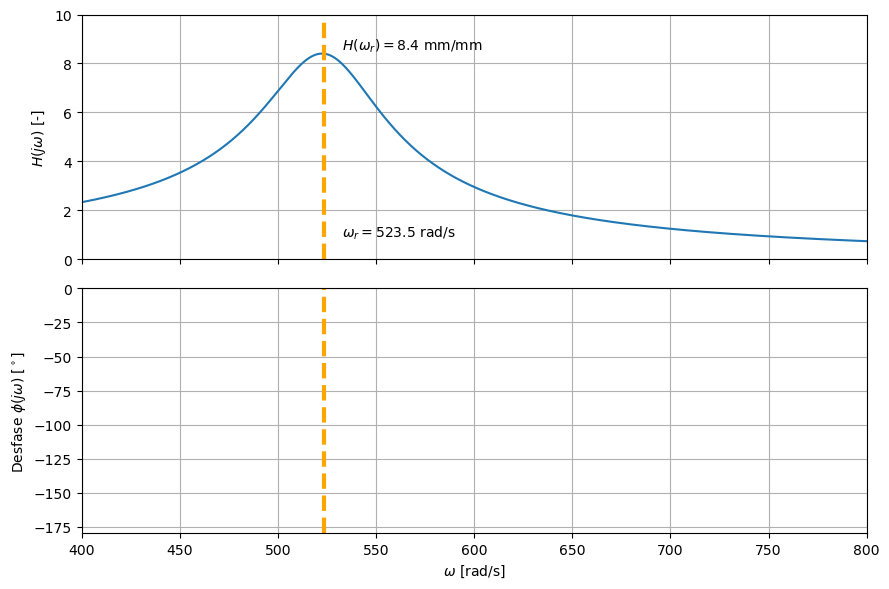

In [ ]:
fig1, axs = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

axs[0].plot(omg, H_omg)
axs[0].set_ylabel(r"$H (j\omega)$ [-]")
axs[0].axvline(omega_r, color='orange', lw=3, ls='--', label=rf'\omega = {omega_r:.1f}$ rad/s')
axs[0].text(omega_r*1.01, min(H_omg), rf' $\;\omega_r = {omega_r:.1f}$ rad/s', ha='left', va='bottom')
axs[0].text(omega_r*1.01, max(H_omg), rf' $\;H(\omega_r) = {max(H_omg):.1f}$ mm/mm', ha='left', va='bottom')
axs[0].set_xlim([400, 800])
axs[0].set_ylim([0, 10])
axs[0].grid()

axs[1].plot(omg, Theta_omg * 180/np.pi - 360) # Convertim a graus i ajustem el desfasament
axs[1].axvline(omega_r, color='orange', lw=3, ls='--', label=rf'\omega = {omega_r:.1f}$ rad/s')
axs[1].set_xlabel(r"$\omega$ [rad/s]")
axs[1].set_ylabel(r"Desfase $\phi(j\omega)$ [$^\circ$]")
axs[1].set_xlim([400, 800])
axs[1].set_ylim([-180, 0])
axs[1].grid()

plt.tight_layout()

B) BODE (llibreria scipy)

In [ ]:
w, mag, phase = signal.bode(sys, omg)
H = k*10**(mag/20) # Convertim a magnitud absoluta (no en dB)

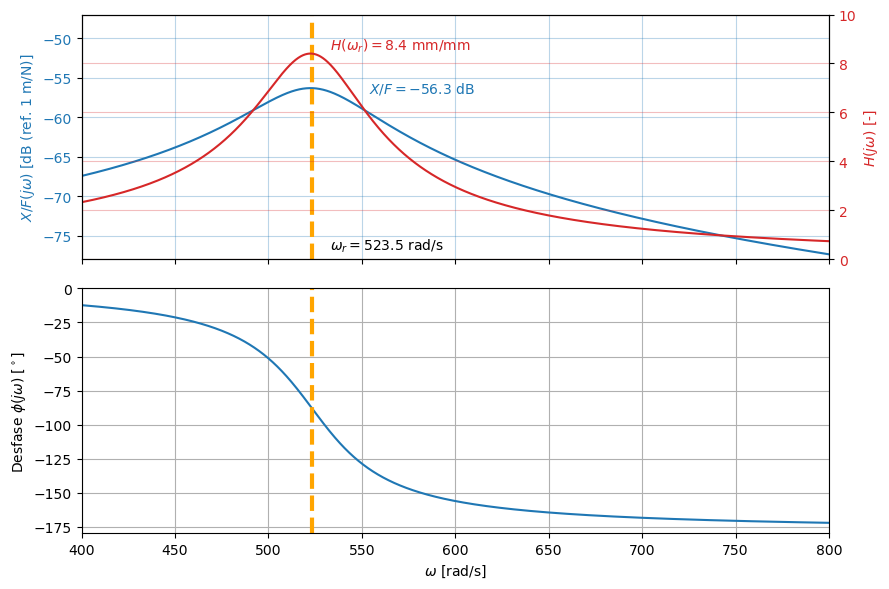

In [ ]:
fig2, axs = plt.subplots(2, 1, figsize=(9, 6), sharex=True)

# --- SUBPLOT 1: doble eix Y ---
ax1 = axs[0]
ax2 = ax1.twinx()

# Magnitud en dB
ax1.plot(w, mag, color='tab:blue', lw=1.5)
ax1.set_ylabel(r"$X/F (j \omega)$ [dB (ref. 1 m/N)]", color='tab:blue')
ax1.set_xlim([400, 800])
ax1.set_ylim([-78, -47])
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Magnitud absoluta
ax2.plot(w, H, color='tab:red', lw=1.5)
ax2.set_ylabel(r"$H (j\omega)$ [-]", color='tab:red')
ax2.set_ylim([0, 10])
ax2.tick_params(axis='y', labelcolor='tab:red')

# Línia vertical comuna
ax1.axvline(omega_r, color='orange', lw=3, ls='--')

# Textos (millor posar-los amb ax1 per coherència)
ax1.text(omega_r*1.01, min(mag), rf' $\;\omega_r = {omega_r:.1f}$ rad/s', ha='left', va='bottom')
ax1.text(omega_r*1.05, max(mag), rf' $\;X/F = {max(mag):.1f}$ dB', ha='left', va='center', color='tab:blue')
ax2.text(omega_r*1.01, max(H), rf' $\;H(\omega_r) = {max(H):.1f}$ mm/mm', ha='left', va='bottom', color='tab:red')

ax1.grid(color='tab:blue', alpha=0.3)
ax2.grid(color='tab:red', alpha=0.3)

# --- SUBPLOT 2: fase ---
axs[1].plot(w, phase)
axs[1].axvline(omega_r, color='orange', lw=3, ls='--')
axs[1].set_xlabel(r"$\omega$ [rad/s]")
axs[1].set_ylabel(r"Desfase $\phi(j\omega)$ [$^\circ$]")
axs[1].set_xlim([400, 800])
axs[1].set_ylim([-180, 0])
axs[1].grid()
plt.tight_layout()